In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Generate some sample data
np.random.seed(42)
X = np.random.rand(100, 5) # 100 samples, 5 features

# Introduce some correlation to make PCA more interesting
X[:, 0] = X[:, 0] * 2 + np.random.randn(100) * 0.1 # Feature 0 is dominant
X[:, 1] = X[:, 0] * 0.5 + np.random.randn(100) * 0.2 # Feature 1 correlated with Feature 0
X[:, 2] = X[:, 2] * 0.8 + np.random.randn(100) * 0.1 # Feature 2 less dominant

df_data = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(5)])

print("Original Data Head:")
display(df_data.head())

Original Data Head:


,feature_0,feature_1,feature_2,feature_3,feature_4
0,0.783256,0.262313,0.539659,0.598658,0.156019
1,0.499606,0.033493,0.607956,0.601115,0.708073
2,0.136211,0.405534,0.748988,0.212339,0.181825
3,0.309119,0.330887,0.334197,0.431945,0.291229
4,1.133864,0.565338,0.240872,0.366362,0.456070


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_data)

print("Scaled Data Head (first 5 rows, all features):")
display(pd.DataFrame(X_scaled, columns=df_data.columns).head())

Scaled Data Head (first 5 rows, all features):


,feature_0,feature_1,feature_2,feature_3,feature_4
0,-0.378435,-0.635476,0.613139,0.265310,-0.971652
1,-0.856298,-1.289852,0.892723,0.273730,0.828999
2,-1.468508,-0.225896,1.470052,-1.058834,-0.887479
3,-1.177212,-0.439370,-0.227947,-0.306115,-0.530632
4,0.212234,0.231107,-0.609983,-0.530907,0.007034


In [4]:
pca = PCA(n_components=2) # Reduce to 2 principal components
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=['principal_component_1', 'principal_component_2'])

print("PCA Transformed Data Head:")
display(df_pca.head())

PCA Transformed Data Head:


,principal_component_1,principal_component_2
0,-0.786578,-0.542644
1,-1.744234,0.722041
2,-1.667803,-1.525714
3,-0.976290,-0.360197
4,0.438506,-0.243208


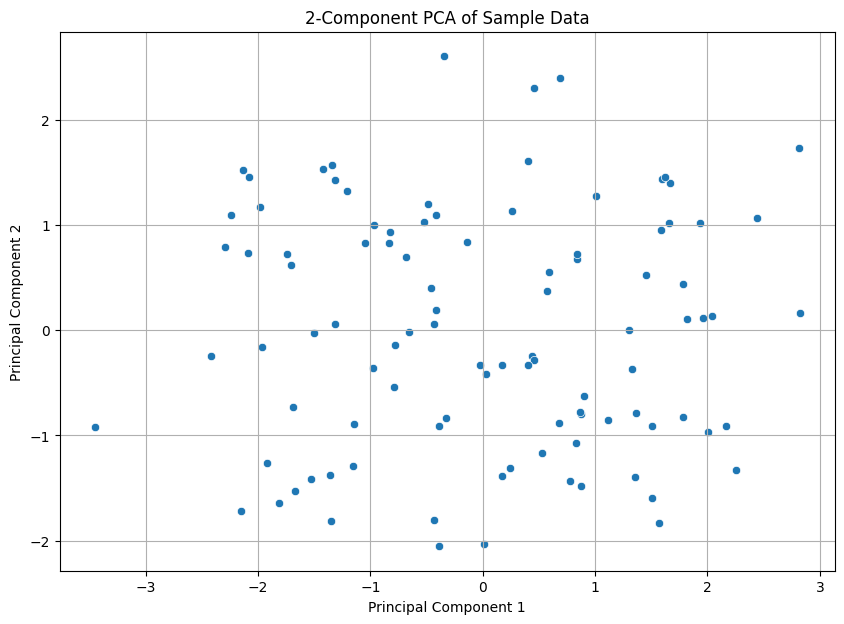

In [5]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='principal_component_1', y='principal_component_2', data=df_pca)
plt.title('2-Component PCA of Sample Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

Explained variance ratio by each principal component: [0.39583741 0.2531317 ]
Total explained variance by 2 components: 0.65


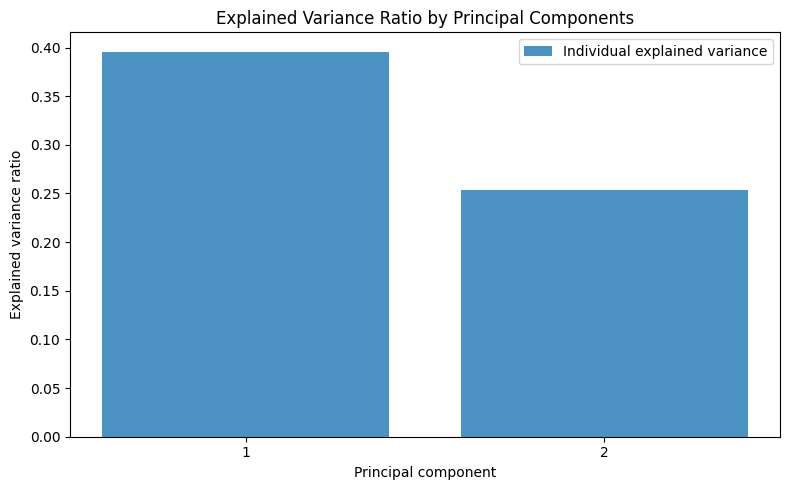

In [6]:
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance ratio by each principal component: {explained_variance}")
print(f"Total explained variance by 2 components: {explained_variance.sum():.2f}")

# Plot the explained variance
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.8, align='center', label='Individual explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component')
plt.title('Explained Variance Ratio by Principal Components')
plt.xticks(range(1, len(explained_variance) + 1))
plt.legend(loc='best')
plt.tight_layout()
plt.show()